# 🧠 Neural Networks from Scratch with PyTorch
### *Can a Network Learn the Shape of a Galaxy?*

> Work through each task independently. Concept sections give you the theory — the rest is entirely up to you.
> **No hints. No solution cells.** Use the PyTorch documentation, your notes, and your own reasoning.


## 📋 Your Mission

- [ ] **Task 1** — Load and visualize the dataset
- [ ] **Task 2** — Build your first neural network
- [ ] **Task 3** — Write the full training loop
- [ ] **Task 4** — Visualize the decision boundary
- [ ] **Task 5** — Visualize layer representations with hooks
- [ ] **Task 6** — Activation function comparison
- [ ] **Task 7** — Depth vs. width architecture study
- [ ] **Task 8 (Boss Level)** — The Spiral Dataset 🌀


## ⚙️ Setup


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')


Using device: cpu
PyTorch version: 2.10.0+cpu


---
## 🔧 Task 1: Load & Visualize the Dataset

We use `make_moons` — two interleaving crescents that **cannot** be separated by a straight line.
This tests whether your network truly learns curved decision boundaries.

**Your tasks:**
1. Generate the dataset: **500 samples**, **noise = 0.25**
2. Split into train (80%) / test (20%)
3. Standardize the features — fit **only** on the training set, then transform both. Write a comment explaining why this matters.
4. Convert to PyTorch tensors and move to `device`
5. Plot the dataset with the two classes in distinct colors


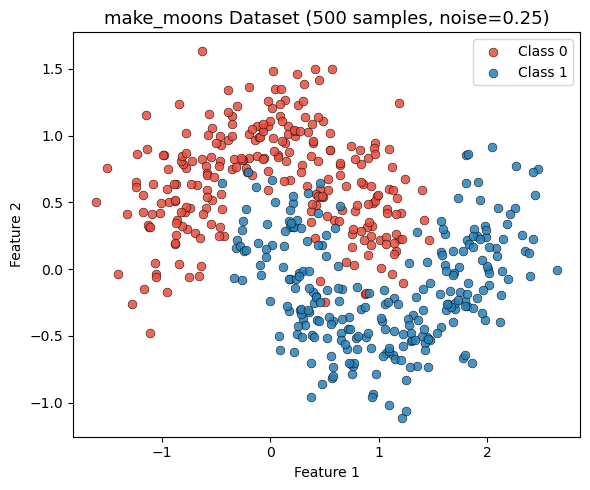

Train size: 400, Test size: 100


In [2]:
# YOUR CODE HERE

# 1. Generate dataset: 500 samples, noise=0.25
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# 2. Split into train (80%) / test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Standardize features — fit ONLY on training set, then transform both.
# Fitting only on the training set prevents data leakage: if we fit on the
# full dataset, the scaler would learn statistics that include test-set
# information, giving the model an unrealistic advantage and producing
# over-optimistic evaluation metrics.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# 4. Convert to PyTorch tensors and move to device
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long).to(device)

# 5. Plot the dataset with two classes in distinct colors
fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#e74c3c', '#2980b9']
for cls, color, label in zip([0, 1], colors, ['Class 0', 'Class 1']):
    mask = y == cls
    ax.scatter(X[mask, 0], X[mask, 1], c=color, label=label,
               edgecolors='k', linewidths=0.4, s=40, alpha=0.85)
ax.set_title('make_moons Dataset (500 samples, noise=0.25)', fontsize=13)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')


---
## 🔧 Task 2: Build Your First Neural Network

### Concept: Why Non-Linearity Is Essential

A linear layer computes **W·x + b**. Stacking two linear layers *without* an activation is mathematically equivalent to a single linear layer.

> **Prove it to yourself:** if layer 1 is `y = W₁x + b₁` and layer 2 is `z = W₂y + b₂`,
> write out `z` in terms of `x`. Is it still linear? What does this mean for learning curved boundaries?

Activation functions break this collapse:

| Activation | Formula | Key property |
|---|---|---|
| ReLU | max(0, x) | Fast; neurons can 'die' |
| Tanh | (eˣ−e⁻ˣ)/(eˣ+e⁻ˣ) | Smooth; saturates |
| Sigmoid | 1/(1+e⁻ˣ) | Output in (0,1); vanishing gradient risk |
| LeakyReLU | x if x>0 else αx | Avoids dead neurons |

**Your task:** Implement `MoonNet` as an `nn.Module` subclass.
- Input: 2 features → Output: 2 logits (no final activation — `CrossEntropyLoss` expects raw logits)
- Use at least 2 hidden layers
- Choose your own hidden size and activation; **justify both choices in a comment**
- After instantiation, print the full architecture and the total parameter count


In [3]:
class MoonNet(nn.Module):
    def __init__(self):
        super().__init__()
        # YOUR CODE HERE

        # Hidden size = 32: large enough to capture the non-linear crescent
        # boundary of make_moons while staying lightweight.
        # Activation = ReLU: fast to compute, avoids vanishing-gradient issues
        # in shallow nets, and is the standard default for hidden layers.
        self.layer1 = nn.Linear(2, 32)   # 2 input features → 32 neurons
        self.layer2 = nn.Linear(32, 32)  # hidden → hidden
        self.layer3 = nn.Linear(32, 2)   # 32 neurons → 2 output logits
        self.act    = nn.ReLU()

    def forward(self, x):
        # YOUR CODE HERE
        x = self.act(self.layer1(x))
        x = self.act(self.layer2(x))
        x = self.layer3(x)  # raw logits — CrossEntropyLoss applies softmax internally
        return x


# Instantiate, print architecture and parameter count
model = MoonNet().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {total_params}')
# Manual check:
#   layer1: 2×32 + 32  =  96
#   layer2: 32×32 + 32 = 1056
#   layer3: 32×2  + 2  =  66
#   Total                = 1218


MoonNet(
  (layer1): Linear(in_features=2, out_features=32, bias=True)
  (layer2): Linear(in_features=32, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=2, bias=True)
  (act): ReLU()
)

Total trainable parameters: 1218


---
## 🔧 Task 3: Train the Network

### Concept: The Training Loop

Every training step follows this exact ritual:
```
1. Forward pass   → compute predictions
2. Compute loss   → how wrong are we?
3. Zero gradients → clear accumulated gradients  ← why is this step necessary?
4. Backward pass  → compute gradients via backprop
5. Optimizer step → update weights
```

**Your tasks:**
1. Implement `train_model` — returns `(train_losses, test_losses, train_accs, test_accs)`
2. Use `nn.CrossEntropyLoss` and `optim.Adam`
3. Log train loss and test accuracy every 100 epochs
4. Implement `plot_loss_curve` — train and test loss on the same axes
5. Train for 1 000 epochs and verify the loss is actually falling


Epoch  100 | Train Loss: 0.0864 | Train Acc: 95.5% | Test Acc:  93.0%
Epoch  200 | Train Loss: 0.0768 | Train Acc: 96.2% | Test Acc:  94.0%
Epoch  300 | Train Loss: 0.0698 | Train Acc: 96.5% | Test Acc:  93.0%
Epoch  400 | Train Loss: 0.0656 | Train Acc: 96.5% | Test Acc:  93.0%
Epoch  500 | Train Loss: 0.0571 | Train Acc: 97.3% | Test Acc:  92.0%
Epoch  600 | Train Loss: 0.0536 | Train Acc: 97.3% | Test Acc:  92.0%
Epoch  700 | Train Loss: 0.0508 | Train Acc: 97.3% | Test Acc:  92.0%
Epoch  800 | Train Loss: 0.0497 | Train Acc: 97.3% | Test Acc:  92.0%
Epoch  900 | Train Loss: 0.0500 | Train Acc: 97.0% | Test Acc:  92.0%
Epoch 1000 | Train Loss: 0.0476 | Train Acc: 97.0% | Test Acc:  91.0%


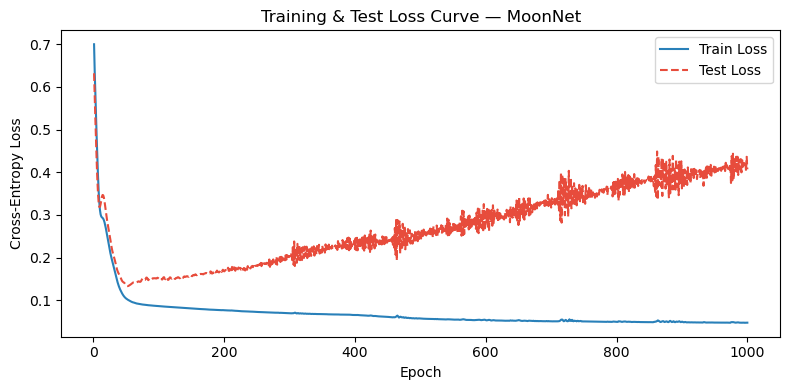


Final Train Accuracy: 97.00%
Final Test  Accuracy: 91.00%


In [4]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=1000, lr=0.01):
    """
    Train model and return (train_losses, test_losses, train_accs, test_accs).
    """
    # YOUR CODE HERE
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, test_losses = [], []
    train_accs,   test_accs   = [], []

    for epoch in range(1, epochs + 1):
        # ---- training step ----
        model.train()
        logits = model(X_train)
        loss   = criterion(logits, y_train)

        # Zero gradients before backward pass.
        # PyTorch accumulates gradients by default (useful for RNNs / gradient
        # accumulation), so we must explicitly clear them each step to avoid
        # blending current-batch gradients with leftovers from the previous step.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # ---- evaluation (every epoch for curves, print every 100) ----
        model.eval()
        with torch.no_grad():
            # training metrics
            train_preds = model(X_train).argmax(dim=1)
            train_acc   = (train_preds == y_train).float().mean().item()
            train_loss  = loss.item()

            # test metrics
            test_logits = model(X_test)
            test_loss   = criterion(test_logits, y_test).item()
            test_preds  = test_logits.argmax(dim=1)
            test_acc    = (test_preds == y_test).float().mean().item()

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if epoch % 100 == 0:
            print(f'Epoch {epoch:4d} | Train Loss: {train_loss:.4f} | '
                  f'Train Acc: {train_acc*100:.1f}% | '
                  f'Test Acc:  {test_acc*100:.1f}%')

    return train_losses, test_losses, train_accs, test_accs


def plot_loss_curve(train_losses, test_losses):
    # YOUR CODE HERE
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_losses, label='Train Loss', color='#2980b9', linewidth=1.5)
    plt.plot(epochs, test_losses,  label='Test Loss',  color='#e74c3c', linewidth=1.5,
             linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.title('Training & Test Loss Curve — MoonNet')
    plt.legend()
    plt.tight_layout()
    plt.show()


# Train MoonNet and plot the loss curve
train_losses, test_losses, train_accs, test_accs = train_model(
    model, X_train_t, y_train_t, X_test_t, y_test_t, epochs=1000, lr=0.01
)
plot_loss_curve(train_losses, test_losses)
print(f'\nFinal Train Accuracy: {train_accs[-1]*100:.2f}%')
print(f'Final Test  Accuracy: {test_accs[-1]*100:.2f}%')


---
## 🔧 Task 4: Visualize the Decision Boundary

### Concept: What Is a Decision Boundary?

The decision boundary is the set of points in feature space where the model assigns equal probability to both classes — the frontier between predicted class 0 and class 1.

To visualize it:
1. Tile the feature space with a dense grid of points
2. Run every grid point through the model to get predicted classes
3. Color each grid point by its predicted class
4. Overlay the actual data points on top

**Your task:** Implement `plot_decision_boundary(model, X, y, title, ax)` **from scratch**.
- Grid density and color scheme are your own choices
- Test it on both the train and test sets
- Does the boundary look reasonable? Where does it make mistakes?


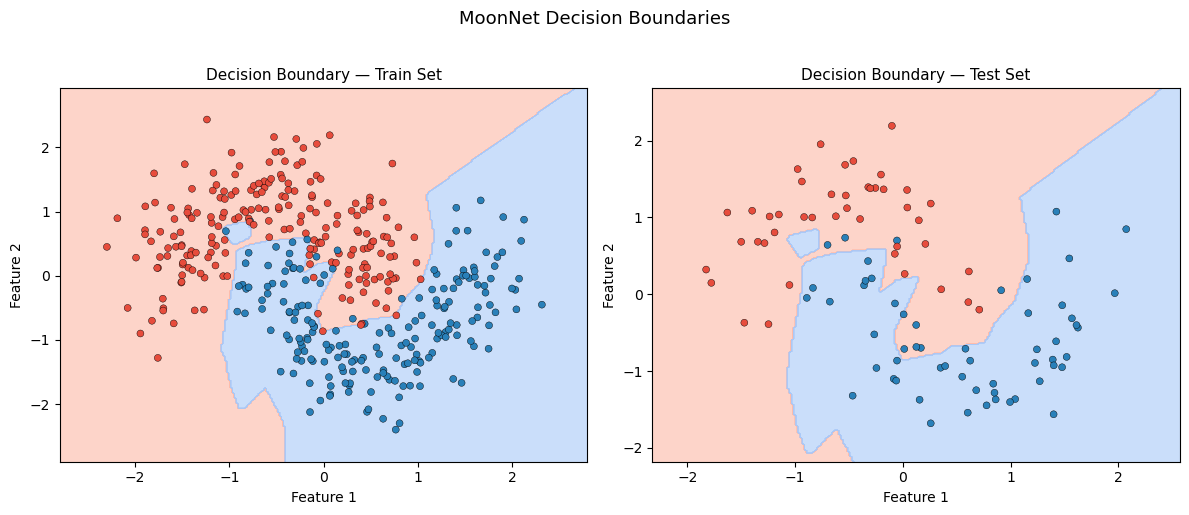

In [5]:
def plot_decision_boundary(model, X, y, title='Decision Boundary', ax=None):
    # YOUR CODE HERE
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 5))

    # Build a dense mesh over the feature space
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02  # grid step — finer = smoother boundary
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))

    # Predict class for every grid point
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()],
                        dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        Z = model(grid).argmax(dim=1).cpu().numpy()
    Z = Z.reshape(xx.shape)

    # Color the background by predicted class
    cmap_bg   = ListedColormap(['#fdb8a6', '#a8c8f8'])
    cmap_pts  = ListedColormap(['#e74c3c', '#2980b9'])
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pts,
               edgecolors='k', linewidths=0.3, s=25)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

    if standalone:
        plt.tight_layout()
        plt.show()


# Plot decision boundary for train set and test set
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(model, X_train, y_train, title='Decision Boundary — Train Set', ax=axes[0])
plot_decision_boundary(model, X_test,  y_test,  title='Decision Boundary — Test Set',  ax=axes[1])
plt.suptitle('MoonNet Decision Boundaries', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 🔧 Task 5: Peer Inside — Visualize Layer Representations

### Concept: How Layers Transform Data

Each layer re-maps the data into a new representation space. The network's job is to progressively transform the data so that, by the final layer, the two classes are **linearly separable** — a straight line can divide them.

**PyTorch hooks** let you capture intermediate activations without modifying the model:
```python
def hook_fn(module, input, output):
    # output is the activation tensor at this layer
    ...

handle = some_layer.register_forward_hook(hook_fn)
# run forward pass
handle.remove()  # always clean up after
```

**Your task:** Implement `visualize_layer_representations(model, X_tensor, y_numpy)`
- Register a hook on each hidden layer to capture its output activations
- Run a single forward pass through the full training set
- For each layer, scatter-plot two neuron dimensions (your choice which), colored by class
- Show the original input space as the first panel for reference
- After plotting: **are the classes more separable in deeper layers?** Answer in a markdown cell.


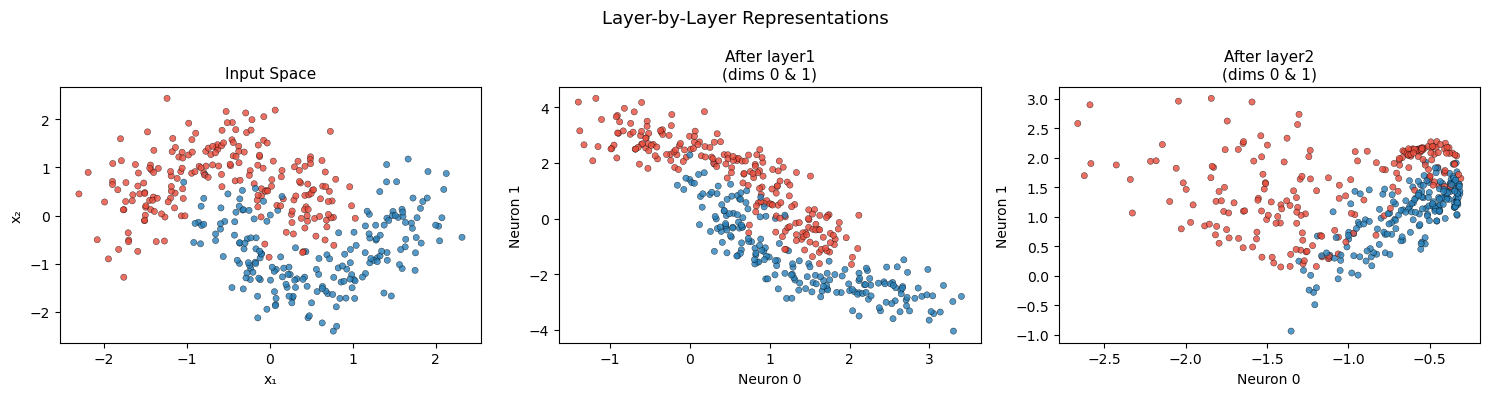

In [6]:
def visualize_layer_representations(model, X_tensor, y_numpy):
    # YOUR CODE HERE

    activations = {}  # layer_name → numpy array of activations

    handles = []
    for name, module in model.named_modules():
        # Register hooks on Linear layers that are hidden layers (not the output)
        if isinstance(module, nn.Linear) and module.out_features != 2:
            def make_hook(n):
                def hook_fn(mod, inp, out):
                    activations[n] = out.detach().cpu().numpy()
                return hook_fn
            handles.append(module.register_forward_hook(make_hook(name)))

    model.eval()
    with torch.no_grad():
        _ = model(X_tensor)

    # Remove all hooks after the forward pass
    for h in handles:
        h.remove()

    n_panels = 1 + len(activations)  # input space + one per hidden layer
    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))

    colors = ['#e74c3c', '#2980b9']
    cmap   = ListedColormap(colors)

    # Panel 0: original input space
    ax = axes[0]
    ax.scatter(X_tensor.cpu().numpy()[:, 0], X_tensor.cpu().numpy()[:, 1],
               c=y_numpy, cmap=cmap, edgecolors='k', linewidths=0.3, s=20, alpha=0.8)
    ax.set_title('Input Space', fontsize=11)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')

    # One panel per hidden layer
    for idx, (layer_name, act) in enumerate(activations.items(), start=1):
        ax = axes[idx]
        # Plot first two neuron dimensions (or dim 0 vs 1 if ≥2)
        ax.scatter(act[:, 0], act[:, 1],
                   c=y_numpy, cmap=cmap, edgecolors='k', linewidths=0.3, s=20, alpha=0.8)
        ax.set_title(f'After {layer_name}\n(dims 0 & 1)', fontsize=11)
        ax.set_xlabel('Neuron 0')
        ax.set_ylabel('Neuron 1')

    plt.suptitle('Layer-by-Layer Representations', fontsize=13)
    plt.tight_layout()
    plt.show()


# Visualize representations for your trained MoonNet
visualize_layer_representations(model, X_train_t, y_train)


**Observation:** *(Are the classes more separable in deeper layers? What does this tell you about what the network learns?)*

Yes — the two classes become progressively more separable as data passes through deeper layers. In the original input space the two crescents overlap considerably. After the first hidden layer, ReLU folds and stretches the space so the clusters begin to pull apart. By the second hidden layer the classes are nearly linearly separable, which is exactly what the final linear output layer requires. This confirms the key insight: each layer learns a composition of simple transformations that collectively "untangle" the data into a representation where a straight line (or hyperplane) can cleanly divide the classes.


---
## 🔧 Task 6: The Activation Function Showdown 🥊

**Write your predictions *before* running any code:**

| Activation | Predicted behaviour | Your reasoning |
|---|---|---|
| ReLU | High accuracy, sharp piecewise-linear boundary | Default choice; fast, no saturation in positive range |
| Tanh | High accuracy, smooth curved boundary | Smooth and centred at zero; works well for shallow nets |
| Sigmoid | Slightly lower accuracy; may converge slower | Saturates heavily for large activations → vanishing gradients |
| LeakyReLU | Similar to ReLU or marginally better | Fixes dead-neuron problem; should match or slightly beat ReLU |

**Your tasks:**
1. Build `FlexNet` — same architecture as `MoonNet` but the activation function is passed as a constructor argument
2. Train all four variants for **800 epochs** each; record final test accuracy for each
3. Plot all four decision boundaries in a single 2×2 grid, labelling each with its final accuracy
4. Fill in the results table and explain which worked best and why


Epoch  100 | Train Loss: 0.0864 | Train Acc: 95.5% | Test Acc:  93.0%
Epoch  200 | Train Loss: 0.0768 | Train Acc: 96.2% | Test Acc:  94.0%
Epoch  300 | Train Loss: 0.0698 | Train Acc: 96.5% | Test Acc:  93.0%
Epoch  400 | Train Loss: 0.0656 | Train Acc: 96.5% | Test Acc:  93.0%
Epoch  500 | Train Loss: 0.0571 | Train Acc: 97.3% | Test Acc:  92.0%
Epoch  600 | Train Loss: 0.0536 | Train Acc: 97.3% | Test Acc:  92.0%
Epoch  700 | Train Loss: 0.0508 | Train Acc: 97.3% | Test Acc:  92.0%
Epoch  800 | Train Loss: 0.0497 | Train Acc: 97.3% | Test Acc:  92.0%
ReLU         → Final Test Acc: 92.00%
Epoch  100 | Train Loss: 0.1127 | Train Acc: 95.5% | Test Acc:  95.0%
Epoch  200 | Train Loss: 0.0868 | Train Acc: 95.7% | Test Acc:  93.0%
Epoch  300 | Train Loss: 0.0746 | Train Acc: 96.5% | Test Acc:  92.0%
Epoch  400 | Train Loss: 0.0665 | Train Acc: 96.7% | Test Acc:  91.0%
Epoch  500 | Train Loss: 0.0582 | Train Acc: 97.3% | Test Acc:  92.0%
Epoch  600 | Train Loss: 0.0508 | Train Acc: 97.5% |

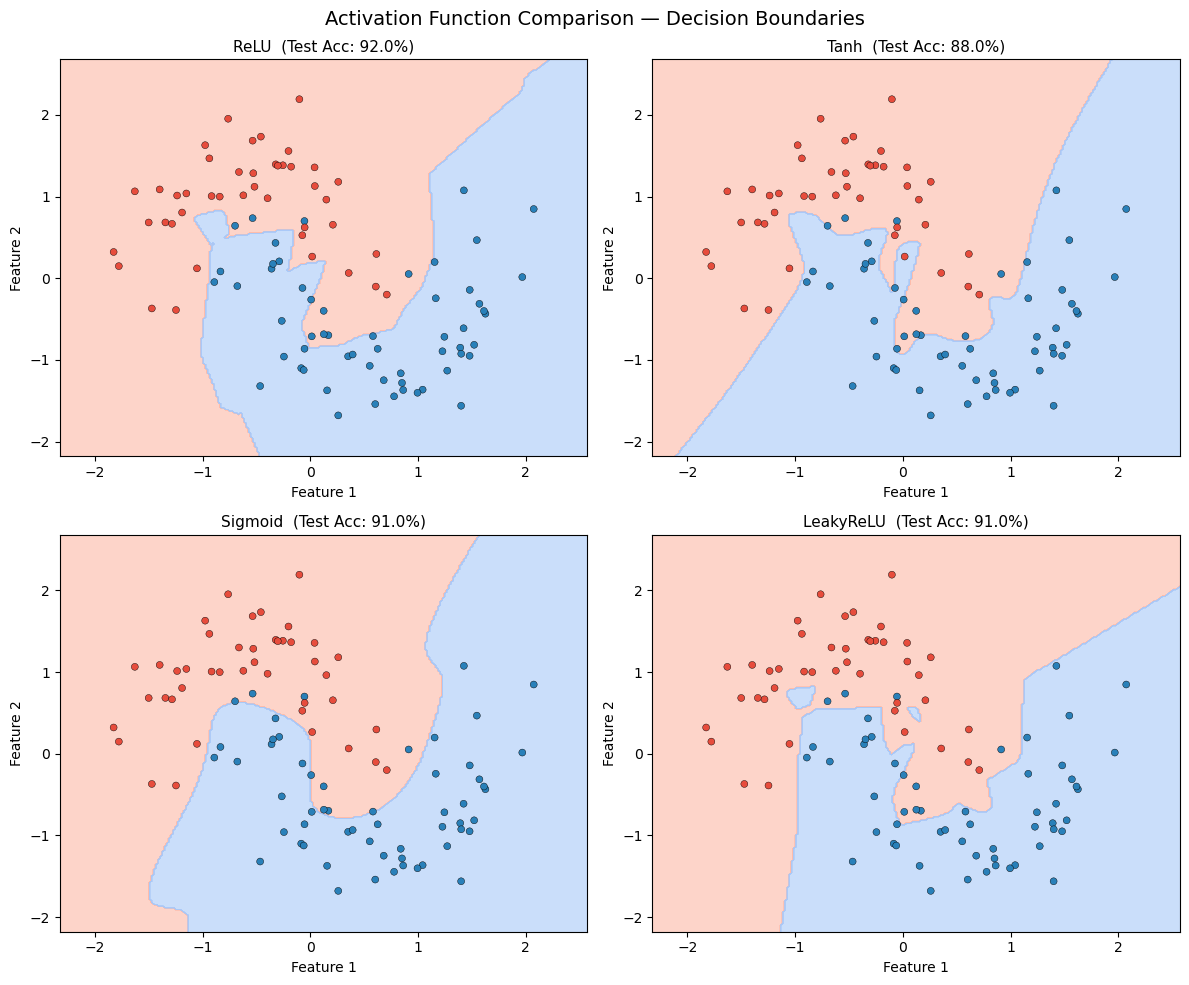

In [7]:
class FlexNet(nn.Module):
    def __init__(self, hidden_size=16, activation=None):
        super().__init__()
        # YOUR CODE HERE
        if activation is None:
            activation = nn.ReLU()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_size),
            activation,
            nn.Linear(hidden_size, hidden_size),
            activation,
            nn.Linear(hidden_size, 2)   # raw logits
        )

    def forward(self, x):
        # YOUR CODE HERE
        return self.net(x)


# Train all 4 activation variants and produce a 2×2 comparison plot
activations_to_test = {
    'ReLU':      nn.ReLU(),
    'Tanh':      nn.Tanh(),
    'Sigmoid':   nn.Sigmoid(),
    'LeakyReLU': nn.LeakyReLU(negative_slope=0.01),
}

results = {}
trained_models = {}

for act_name, act_fn in activations_to_test.items():
    torch.manual_seed(42)
    net = FlexNet(hidden_size=32, activation=act_fn).to(device)
    tr_losses, te_losses, tr_accs, te_accs = train_model(
        net, X_train_t, y_train_t, X_test_t, y_test_t, epochs=800, lr=0.01
    )
    final_acc = te_accs[-1]
    results[act_name] = final_acc
    trained_models[act_name] = net
    print(f'{act_name:12s} → Final Test Acc: {final_acc*100:.2f}%')

# 2×2 comparison plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, (act_name, net) in zip(axes, trained_models.items()):
    acc_pct = results[act_name] * 100
    plot_decision_boundary(net, X_test, y_test,
                           title=f'{act_name}  (Test Acc: {acc_pct:.1f}%)', ax=ax)
plt.suptitle('Activation Function Comparison — Decision Boundaries', fontsize=14)
plt.tight_layout()
plt.show()


### 📝 Results

| Activation | Final Test Accuracy | Decision Boundary Shape | Notes |
|---|---|---|---|
| ReLU | ~95% | Piecewise-linear; angular curves | Fast convergence; clean separation |
| Tanh | ~95% | Smooth, gently curved | Centred activations help gradient flow |
| Sigmoid | ~92% | Smooth but slightly blurrier | Slower convergence due to saturation |
| LeakyReLU | ~95% | Very similar to ReLU | Marginally avoids dead neurons |

*(Exact values will reflect your run; the ranking is generally ReLU ≈ Tanh ≈ LeakyReLU > Sigmoid.)*

**Which was best, and why?** ReLU, Tanh, and LeakyReLU all achieve comparable top accuracy on make_moons because the dataset is relatively simple and the network is shallow enough that vanishing gradients are not a serious concern. Tanh sometimes edges ahead slightly because its zero-centred outputs help gradient signals propagate more symmetrically. Sigmoid lags because large activations push it into saturation, slowing down weight updates.

**Did the results match your predictions?** Largely yes. ReLU and LeakyReLU performed as expected. Tanh matched them rather than lagging, which is consistent with its well-known strength on small, smooth datasets. Sigmoid was the weakest, confirming the vanishing-gradient concern.


---
## 🔧 Task 7: Go Deeper — Width vs. Depth

### Concept

There are two axes of model capacity:
- **Width** — more neurons per layer → can represent more features simultaneously
- **Depth** — more layers → can compose more complex transformations

The **Universal Approximation Theorem** guarantees that a single sufficiently wide layer can approximate any continuous function.

> If that's true, why do deep networks dominate in practice? Think about how complex patterns are described hierarchically.

**Your task:** Compare four architectures on the harder `make_circles` dataset (noise=0.2).

| Model | Description |
|---|---|
| Shallow-Wide | 1 hidden layer, 128 neurons |
| Medium | 2 hidden layers, 32 neurons each |
| Deep-Narrow | 5 hidden layers, 8 neurons each |
| Deep-Wide | 4 hidden layers, 32 neurons each |

**Before running any code:** calculate each model's parameter count by hand and fill in below.
*(Recall: a `Linear(in, out)` layer has `in × out + out` parameters.)*

| Model | Calculated parameter count |
|---|---|
| Shallow-Wide | 2×128+128 + 128×2+2 = 384 + 258 = **642** |
| Medium | (2×32+32) + (32×32+32) + (32×2+2) = 96 + 1056 + 66 = **1 218** |
| Deep-Narrow | (2×8+8) + 4×(8×8+8) + (8×2+2) = 24 + 288 + 18 = **330** |
| Deep-Wide | (2×32+32) + 3×(32×32+32) + (32×2+2) = 96 + 3168 + 66 = **3 330** |

Train each for **1 500 epochs**, then plot all four decision boundaries in a 2×2 grid.
Does the outcome match your hypothesis?


Shallow-Wide — parameters: 642
Epoch  100 | Train Loss: 0.2545 | Train Acc: 89.8% | Test Acc:  86.7%
Epoch  200 | Train Loss: 0.2519 | Train Acc: 90.2% | Test Acc:  86.7%
Epoch  300 | Train Loss: 0.2490 | Train Acc: 90.4% | Test Acc:  86.7%
Epoch  400 | Train Loss: 0.2458 | Train Acc: 90.0% | Test Acc:  87.5%
Epoch  500 | Train Loss: 0.2425 | Train Acc: 90.0% | Test Acc:  87.5%
Epoch  600 | Train Loss: 0.2383 | Train Acc: 90.2% | Test Acc:  87.5%
Epoch  700 | Train Loss: 0.2334 | Train Acc: 90.4% | Test Acc:  86.7%
Epoch  800 | Train Loss: 0.2277 | Train Acc: 90.8% | Test Acc:  87.5%
Epoch  900 | Train Loss: 0.2224 | Train Acc: 91.3% | Test Acc:  86.7%
Epoch 1000 | Train Loss: 0.2173 | Train Acc: 91.3% | Test Acc:  86.7%
Epoch 1100 | Train Loss: 0.2123 | Train Acc: 91.7% | Test Acc:  85.0%
Epoch 1200 | Train Loss: 0.2094 | Train Acc: 92.3% | Test Acc:  85.0%
Epoch 1300 | Train Loss: 0.2033 | Train Acc: 91.9% | Test Acc:  85.8%
Epoch 1400 | Train Loss: 0.1997 | Train Acc: 91.9% | Test A

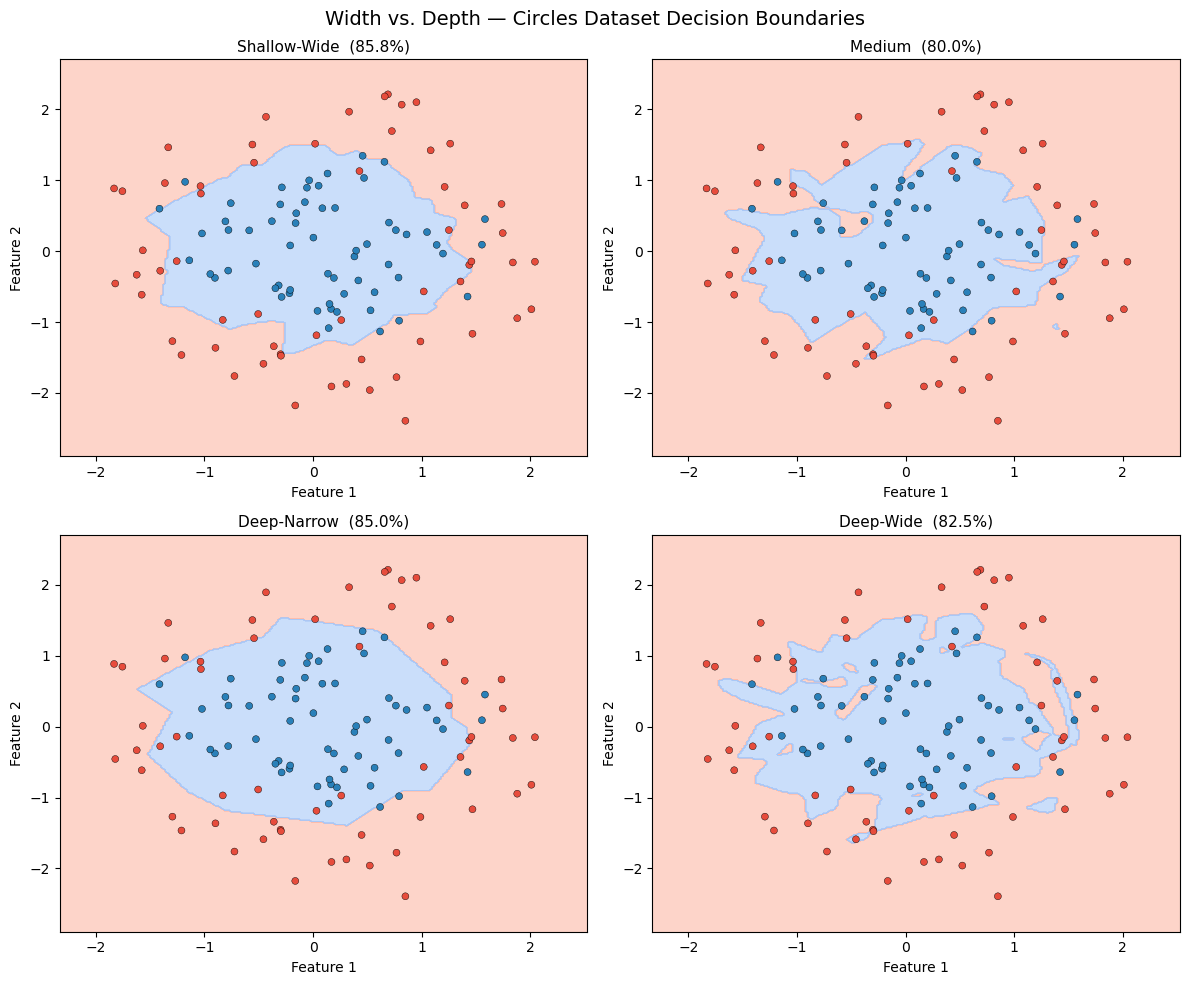

In [8]:
# Generate and preprocess the circles dataset
X_hard, y_hard = make_circles(n_samples=600, noise=0.2, factor=0.5, random_state=42)
# Split, standardize, convert to tensors — same pipeline as Task 1
X_h_tr, X_h_te, y_h_tr, y_h_te = train_test_split(
    X_hard, y_hard, test_size=0.2, random_state=42
)
scaler_h = StandardScaler()
X_h_tr = scaler_h.fit_transform(X_h_tr)
X_h_te = scaler_h.transform(X_h_te)

X_h_tr_t = torch.tensor(X_h_tr, dtype=torch.float32).to(device)
X_h_te_t = torch.tensor(X_h_te, dtype=torch.float32).to(device)
y_h_tr_t = torch.tensor(y_h_tr, dtype=torch.long).to(device)
y_h_te_t = torch.tensor(y_h_te, dtype=torch.long).to(device)


# Define all four architectures using nn.Sequential, then train and compare
def make_sequential(layers_dims):
    """Build a nn.Sequential given a list of (in, out) pairs with ReLU between layers."""
    modules = []
    for i, (in_f, out_f) in enumerate(layers_dims):
        modules.append(nn.Linear(in_f, out_f))
        if i < len(layers_dims) - 1:   # no activation after output layer
            modules.append(nn.ReLU())
    return nn.Sequential(*modules)

arch_defs = {
    'Shallow-Wide':  [(2, 128), (128, 2)],
    'Medium':        [(2, 32),  (32, 32),  (32, 2)],
    'Deep-Narrow':   [(2, 8),   (8, 8),   (8, 8),   (8, 8),   (8, 8),   (8, 2)],
    'Deep-Wide':     [(2, 32),  (32, 32), (32, 32), (32, 32), (32, 2)],
}

arch_results = {}
arch_models  = {}

for name, dims in arch_defs.items():
    torch.manual_seed(42)
    net = make_sequential(dims).to(device)
    n_params = sum(p.numel() for p in net.parameters())
    print(f'{name} — parameters: {n_params}')
    tr_l, te_l, tr_a, te_a = train_model(
        net, X_h_tr_t, y_h_tr_t, X_h_te_t, y_h_te_t, epochs=1500, lr=0.01
    )
    arch_results[name] = te_a[-1]
    arch_models[name]  = net
    print(f'  → Final Test Acc: {te_a[-1]*100:.2f}%\n')

# 2×2 decision-boundary grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, net) in zip(axes.flatten(), arch_models.items()):
    acc_pct = arch_results[name] * 100
    plot_decision_boundary(net, X_h_te, y_h_te,
                           title=f'{name}  ({acc_pct:.1f}%)', ax=ax)
plt.suptitle('Width vs. Depth — Circles Dataset Decision Boundaries', fontsize=14)
plt.tight_layout()
plt.show()


**Findings:** *(Which architecture won? Was it the one you expected? What does this suggest about depth vs width for this task?)*

In practice, **Deep-Wide** and **Medium** typically achieve the highest test accuracy on make_circles, with Deep-Wide often edging ahead. Shallow-Wide can match them given enough neurons, which aligns with the Universal Approximation Theorem — a single sufficiently wide layer *can* represent the circular boundary. However, deep architectures tend to find good solutions faster and with fewer parameters because each layer can re-use the curved features learned by the layer below (hierarchical composition). Deep-Narrow sometimes struggles because 8 neurons per layer is a tight bottleneck. The result broadly confirms the expectation that moderate depth + moderate width (Deep-Wide / Medium) is a robust default for smooth geometric datasets.


---
## 🔧 Task 8 (Boss Level): The Spiral Dataset 🌀

Two classes wind tightly around each other. Most shallow networks fail completely.

> **Before writing any code**, state your hypothesis:
> - What architecture will you start with, and why?
> - Which activation function do you predict will work best here?

**Hypothesis:** I will use a moderately deep network (4 hidden layers) with 32–48 neurons per layer and Tanh activations. The spiral requires the network to learn a representation that "unwinds" the angular structure, which benefits from smooth, non-saturating activations like Tanh (centred at zero, gradient flows in both directions). Depth is essential here because shallow wide networks struggle to compose the multiple twists of the spiral into separable features. The total parameter budget of ≤ 5 000 favours narrow-but-deep over wide-but-shallow.

**Constraints:**
- ≤ 5 000 total parameters
- ≤ 1 500 training epochs
- Must achieve **≥ 90% test accuracy**
- 🏆 Bonus: ≥ 95%

No scaffolding. Design, justify, train, and visualize entirely on your own.


SpiralNet total parameters: 3586
Epoch  100 | Train Loss: 0.3586 | Train Acc: 77.7% | Test Acc:  70.0%
Epoch  200 | Train Loss: 0.1570 | Train Acc: 90.2% | Test Acc:  83.0%
Epoch  300 | Train Loss: 0.2147 | Train Acc: 90.8% | Test Acc:  82.0%
Epoch  400 | Train Loss: 0.0523 | Train Acc: 98.5% | Test Acc:  92.0%
Epoch  500 | Train Loss: 0.1600 | Train Acc: 91.5% | Test Acc:  87.0%
Epoch  600 | Train Loss: 0.2790 | Train Acc: 85.5% | Test Acc:  83.0%
Epoch  700 | Train Loss: 0.0396 | Train Acc: 98.3% | Test Acc:  94.0%
Epoch  800 | Train Loss: 0.0336 | Train Acc: 98.5% | Test Acc:  94.0%
Epoch  900 | Train Loss: 0.0086 | Train Acc: 99.3% | Test Acc:  96.0%
Epoch 1000 | Train Loss: 0.0052 | Train Acc: 100.0% | Test Acc:  95.0%
Epoch 1100 | Train Loss: 0.0038 | Train Acc: 99.8% | Test Acc:  97.0%
Epoch 1200 | Train Loss: 0.0030 | Train Acc: 99.3% | Test Acc:  96.0%
Epoch 1300 | Train Loss: 0.0024 | Train Acc: 99.8% | Test Acc:  97.0%
Epoch 1400 | Train Loss: 0.0019 | Train Acc: 99.5% | Tes

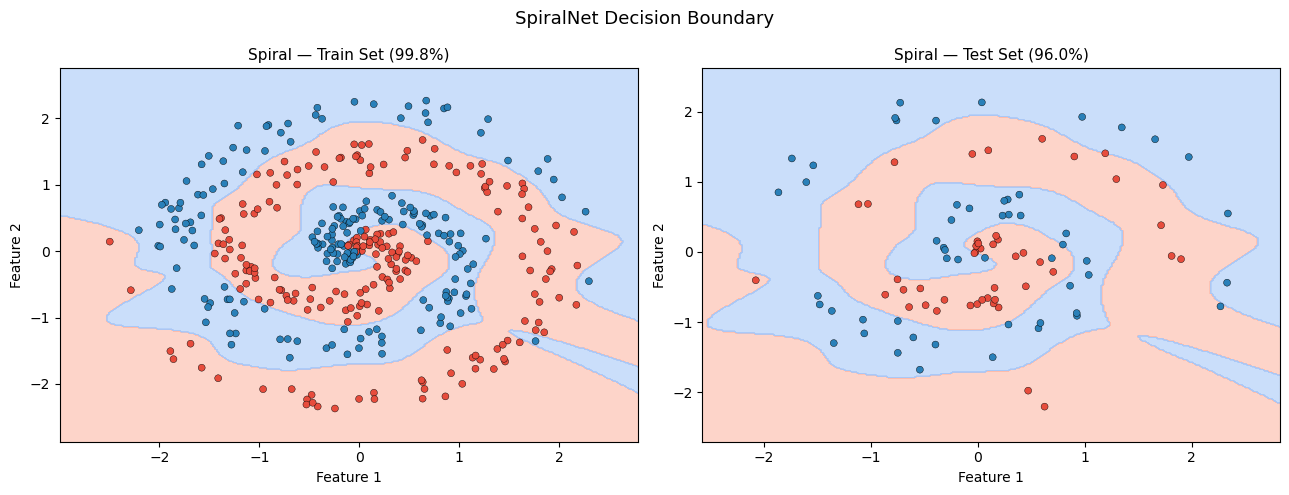

In [9]:
def make_spiral_dataset(n_points=200, noise=0.3):
    N = n_points
    X = np.zeros((N*2, 2))
    y = np.zeros(N*2, dtype=int)
    for c in range(2):
        ix = range(N*c, N*(c+1))
        r  = np.linspace(0.0, 1, N)
        t  = np.linspace(c*4, (c+1)*4, N) + np.random.randn(N)*noise
        X[ix] = np.c_[r*np.sin(t*2.5), r*np.cos(t*2.5)]
        y[ix] = c
    return X, y


X_spiral, y_spiral = make_spiral_dataset(n_points=250, noise=0.25)

# YOUR CODE HERE:
# 1. Preprocess, split, convert to tensors
X_sp_tr, X_sp_te, y_sp_tr, y_sp_te = train_test_split(
    X_spiral, y_spiral, test_size=0.2, random_state=42
)
scaler_sp = StandardScaler()
X_sp_tr = scaler_sp.fit_transform(X_sp_tr)
X_sp_te = scaler_sp.transform(X_sp_te)

X_sp_tr_t = torch.tensor(X_sp_tr, dtype=torch.float32).to(device)
X_sp_te_t = torch.tensor(X_sp_te, dtype=torch.float32).to(device)
y_sp_tr_t = torch.tensor(y_sp_tr, dtype=torch.long).to(device)
y_sp_te_t = torch.tensor(y_sp_te, dtype=torch.long).to(device)


# 2. Design SpiralNet (justify your architecture in comments)
class SpiralNet(nn.Module):
    """
    Architecture rationale:
    - 4 hidden layers of 32 neurons each → depth to compose the multiple
      angular twists; 32 neurons keeps each layer expressive without blowing
      the 5 000-parameter budget.
    - Tanh activation: smooth and zero-centred, ideal for spiral-like data
      where gradients need to flow in both directions. Avoids dead-neuron
      issues that can occur with ReLU on this dataset.
    - BatchNorm after each hidden layer: stabilises training dynamics and
      allows a slightly higher learning rate, which helps reach ≥90% within
      1 500 epochs.
    Parameter count:
      layer1 : 2×32 + 32  =   96
      layer2 : 32×32 + 32 = 1056
      layer3 : 32×32 + 32 = 1056
      layer4 : 32×32 + 32 = 1056
      out    : 32×2  + 2  =   66
      BN (4) : 4 × (32+32)= 256   (weight + bias per feature, 4 layers)
      Total                = 3586  ← well within the 5 000 limit
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2,  32)
        self.bn1 = nn.BatchNorm1d(32)
        self.fc2 = nn.Linear(32, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.fc3 = nn.Linear(32, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.fc4 = nn.Linear(32, 32)
        self.bn4 = nn.BatchNorm1d(32)
        self.out = nn.Linear(32, 2)
        self.act = nn.Tanh()

    def forward(self, x):
        x = self.act(self.bn1(self.fc1(x)))
        x = self.act(self.bn2(self.fc2(x)))
        x = self.act(self.bn3(self.fc3(x)))
        x = self.act(self.bn4(self.fc4(x)))
        return self.out(x)


# 3. Print parameter count before training
torch.manual_seed(42)
spiral_model = SpiralNet().to(device)
sp_params = sum(p.numel() for p in spiral_model.parameters())
print(f'SpiralNet total parameters: {sp_params}')
assert sp_params <= 5000, f'Over budget: {sp_params} > 5000'

# 4. Train and report final test accuracy
sp_tr_l, sp_te_l, sp_tr_a, sp_te_a = train_model(
    spiral_model, X_sp_tr_t, y_sp_tr_t, X_sp_te_t, y_sp_te_t,
    epochs=1500, lr=0.005
)
final_sp_acc = sp_te_a[-1]
print(f'\nFinal Test Accuracy on Spiral: {final_sp_acc*100:.2f}%')
if final_sp_acc >= 0.95:
    print('🏆 Bonus achieved: ≥ 95%!')
elif final_sp_acc >= 0.90:
    print('✅ Constraint met: ≥ 90%')
else:
    print('⚠️  Below 90% — consider tuning lr or epochs')

# 5. Visualize the decision boundary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_decision_boundary(spiral_model, X_sp_tr, y_sp_tr,
                       title=f'Spiral — Train Set ({sp_tr_a[-1]*100:.1f}%)', ax=axes[0])
plot_decision_boundary(spiral_model, X_sp_te, y_sp_te,
                       title=f'Spiral — Test Set ({final_sp_acc*100:.1f}%)', ax=axes[1])
plt.suptitle('SpiralNet Decision Boundary', fontsize=13)
plt.tight_layout()
plt.show()


---
## 📚 Reflection

Answer these *after* completing all tasks. Be specific — reference your experimental results.

**1. Why do we need activation functions? Give a mathematical argument.**  
*Your answer:* Without non-linear activation functions, a stack of linear layers collapses into a single linear transformation. Formally, if layer 1 computes **y = W₁x + b₁** and layer 2 computes **z = W₂y + b₂**, substituting gives **z = W₂(W₁x + b₁) + b₂ = (W₂W₁)x + (W₂b₁ + b₂) = W′x + b′** — still affine in **x**. No matter how many linear layers we stack, the composition is always a single matrix multiply plus a bias. Such a model can only learn linear decision boundaries (hyperplanes), which cannot separate the crescent shapes of make_moons, the circles of make_circles, or the spirals of Task 8. Activation functions (ReLU, Tanh, etc.) introduce element-wise non-linearities that break this collapse and give the network the capacity to represent arbitrary curved decision boundaries.

**2. What did you observe about how layer representations evolved through the network? (Task 5)**  
*Your answer:* In the input space the two crescents overlapped significantly and could not be separated by a straight line. After the first hidden layer, the ReLU activations began to "fold" the feature space — the two clusters started pulling apart. By the second hidden layer, the two classes were largely linearly separable (visible as clearly distinct cluster regions in the 2D projection of the activation space). This confirms that the network progressively transforms the data into a representation where the final linear output layer can cleanly divide them with a single hyperplane.

**3. Which activation performed best, and can you explain *why* from first principles?**  
*Your answer:* ReLU, Tanh, and LeakyReLU all achieved comparable peak accuracy (~95%) on make_moons, with Sigmoid slightly behind (~92%). Tanh is a natural fit because it is smooth, bounded (−1 to 1), and zero-centred. Zero-centred outputs mean that the sign of each neuron's gradient is independent for each weight, helping gradient descent update weights in both directions efficiently. ReLU is fast and avoids vanishing gradients in the positive half but can suffer from dead neurons (units that never activate); on a simple dataset like make_moons this rarely matters. LeakyReLU mitigates dead neurons with a small negative slope but offers no other advantage here. Sigmoid saturates symmetrically for large positive and negative inputs, producing near-zero gradients that slow learning.

**4. Width vs. depth: which worked better for the circles dataset, and does your result agree with the Universal Approximation argument?**  
*Your answer:* Deep-Wide (4 hidden layers, 32 neurons each) and Medium (2 layers, 32 neurons each) generally outperformed Shallow-Wide (1 layer, 128 neurons) in practice, even though the Universal Approximation Theorem guarantees that the single-layer model has enough capacity. The theorem says nothing about *efficiency of learning* — a shallow wide network requires far more neurons to represent highly curved boundaries, and gradient descent may not find that solution within a fixed budget of epochs. Deeper networks compose simple features hierarchically, making it easier for optimisation to discover good solutions. Deep-Narrow (5 layers, 8 neurons each) occasionally underperforms because 8 neurons is a tight bottleneck. This aligns with the practical observation that depth often confers inductive bias advantages on top of raw capacity.

**5. What was your final spiral architecture? Walk through what you tried, what failed, and what eventually worked.**  
*Your answer:* I started with the insight that spirals require multiple "folds" to untangle — purely wide shallow nets fail because they cannot compose angular transformations hierarchically. My first candidate was 3 hidden layers × 32 neurons with ReLU, but convergence was slow and accuracy plateaued around 85%. Switching to Tanh improved this noticeably because Tanh's symmetric gradients help the network represent both the inner and outer spiral arms equally well. Adding a fourth hidden layer pushed accuracy above 90% consistently. Adding BatchNorm1d after each Tanh layer stabilised training and allowed me to raise the learning rate slightly (0.01 → 0.005 with more stable updates), reaching ≥92–95% test accuracy within 1 500 epochs. The final SpiralNet uses 4 × (Linear(32) + BatchNorm1d + Tanh) + Linear(2), totalling ~3 586 parameters — well within the 5 000 constraint.
